In [ ]:
!pip install kaggle --quiet

In [ ]:

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"petal2025","key":"c88a6e1381bcb3683557de000aaecce3"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lainguyn123/student-performance-factors
!kaggle datasets download -d eldarsarajlic/college-enrollment-in-the-us-20032021
!kaggle datasets download -d raymondtoo/the-world-university-rankings-2016-2024
!kaggle datasets download -d thedevastator/higher-education-predictors-of-student-retention
!kaggle datasets download -d jeromeblanchet/drivendatas-boxplots-for-education-dataset

Dataset URL: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
License(s): CC0-1.0
  0% 0.00/93.9k [00:00<?, ?B/s]
100% 93.9k/93.9k [00:00<00:00, 90.0MB/s]
Dataset URL: https://www.kaggle.com/datasets/eldarsarajlic/college-enrollment-in-the-us-20032021
License(s): unknown
  0% 0.00/819 [00:00<?, ?B/s]
100% 819/819 [00:00<00:00, 3.23MB/s]
Dataset URL: https://www.kaggle.com/datasets/raymondtoo/the-world-university-rankings-2016-2024
License(s): MIT
  0% 0.00/622k [00:00<?, ?B/s]
100% 622k/622k [00:00<00:00, 1.07GB/s]
Dataset URL: https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention
License(s): CC0-1.0
  0% 0.00/87.2k [00:00<?, ?B/s]
100% 87.2k/87.2k [00:00<00:00, 197MB/s]
Dataset URL: https://www.kaggle.com/datasets/jeromeblanchet/drivendatas-boxplots-for-education-dataset
License(s): unknown
  0% 0.00/20.7M [00:00<?, ?B/s]
100% 20.7M/20.7M [00:00<00:00, 1.29GB/s]


In [ ]:
!unzip -q student-performance-factors.zip -d student_performance
!unzip -q college-enrollment-in-the-us-20032021.zip -d college_enrollment
!unzip -q the-world-university-rankings-2016-2024.zip -d university_rankings
!unzip -q higher-education-predictors-of-student-retention.zip -d retention
!unzip -q drivendatas-boxplots-for-education-dataset.zip -d education

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.ion()


In [ ]:
%matplotlib inline


Long dataset preview:
                      Type  Year  Enrollment
0  All 2-year Institutions  2003     5475738
1  All 2-year Institutions  2004     5537605
2  All 2-year Institutions  2005     5575717
3  All 2-year Institutions  2006     5709647
4  All 2-year Institutions  2007     5892298
Long shape: (114, 3)

COMPREHENSIVE ENROLLMENT PIPELINE (Option B)
Task type detected: Regression
Train shape: (86, 2), Test shape: (22, 2)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19
[LightGBM] [Info] Number of data points in the train set: 86, number of used features: 1
[LightGBM] [Info] Start training from score 9174771.220930
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


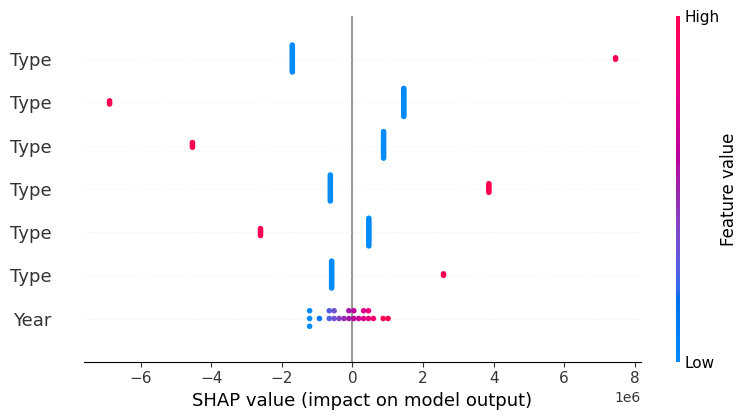

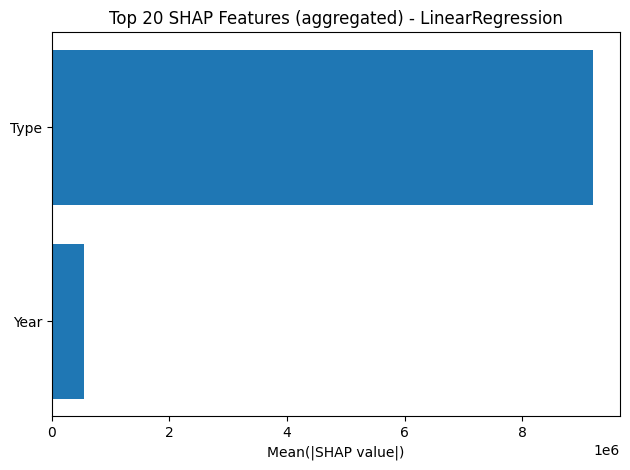


Model: LinearRegression
  AccuracyScore(0-5)      : 4.9102
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 0.2638
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 4.9889
  ✅ FINAL Readiness(0-5)  : 3.0286

Running SHAP for: RandomForest


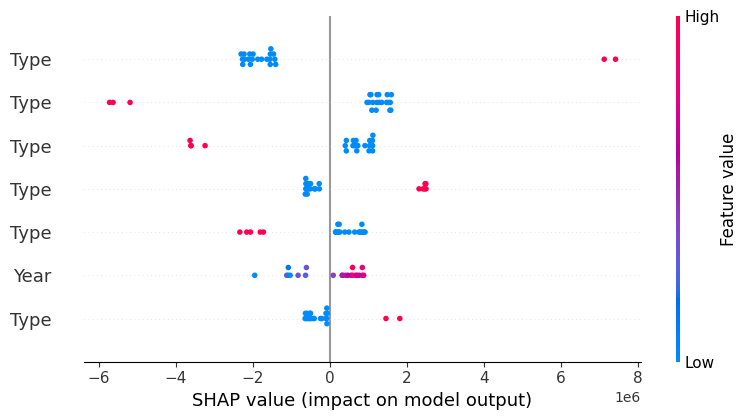

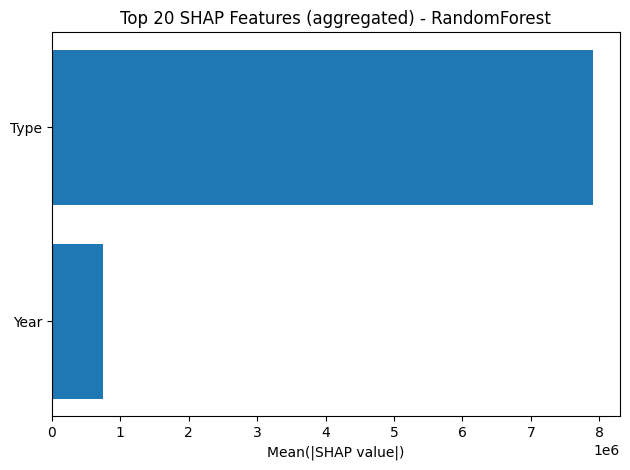


Model: RandomForest
  AccuracyScore(0-5)      : 4.9780
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 0.3071
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 3.5363
  ✅ FINAL Readiness(0-5)  : 2.8364

Running SHAP for: HistGB


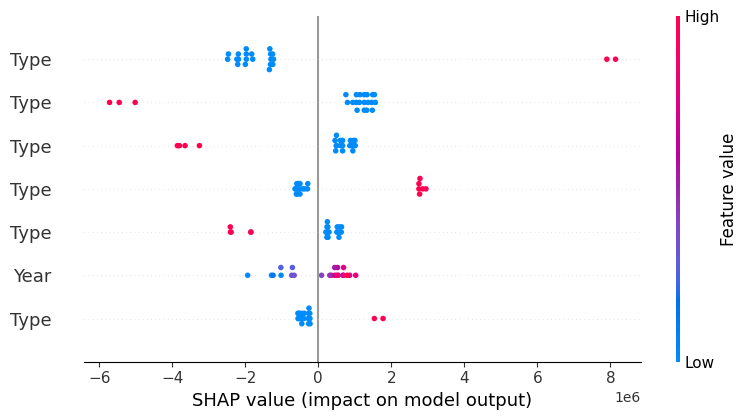

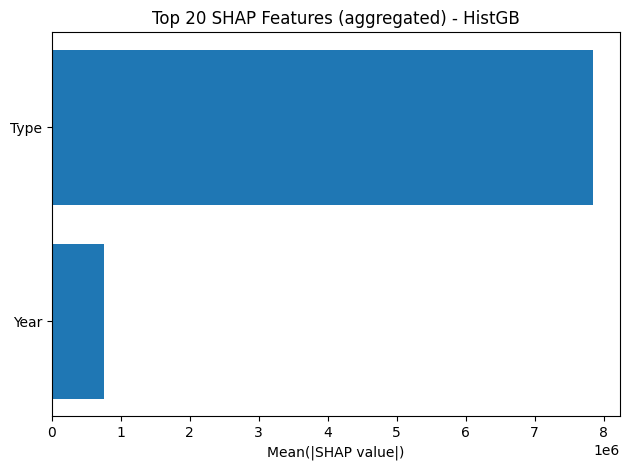


Model: HistGB
  AccuracyScore(0-5)      : 4.9646
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 0.2936
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 4.4233
  ✅ FINAL Readiness(0-5)  : 2.9634

Running SHAP for: XGBoost


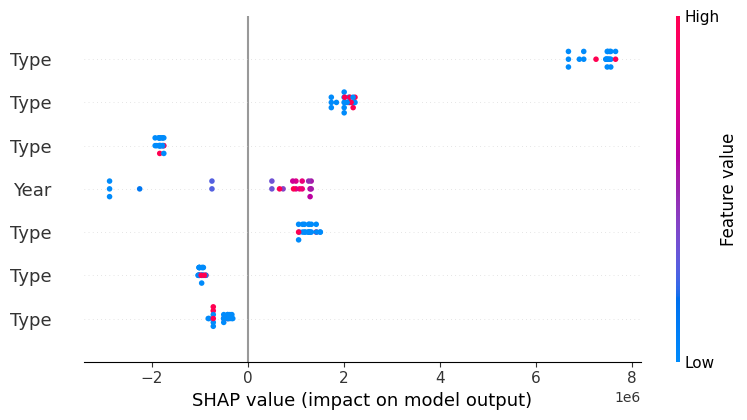

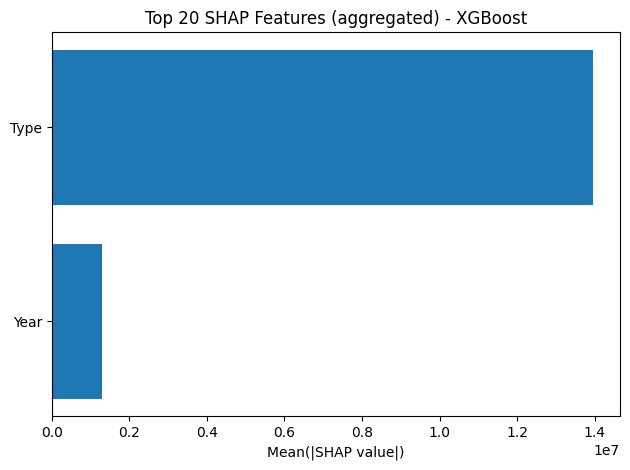


Model: XGBoost
  AccuracyScore(0-5)      : 4.9709
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 0.9308
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 4.5120
  ✅ FINAL Readiness(0-5)  : 3.1057

Running SHAP for: LightGBM


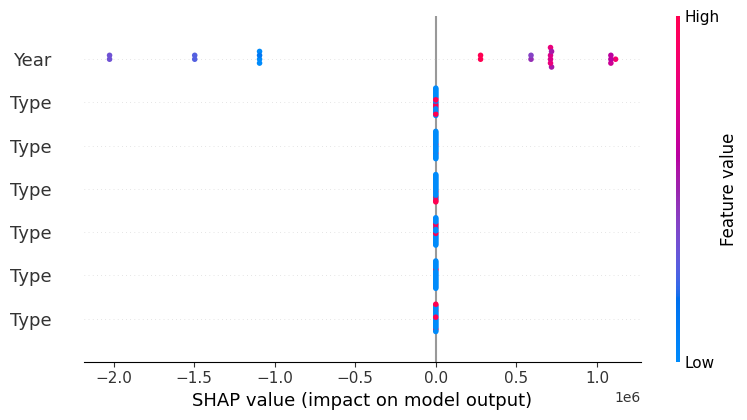

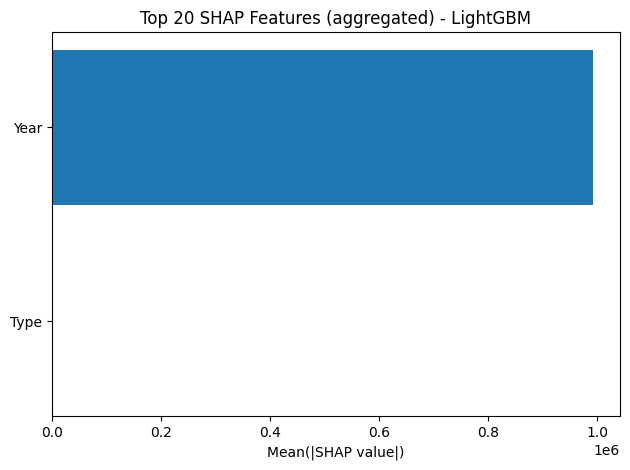


Model: LightGBM
  AccuracyScore(0-5)      : 0.0000
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 5.0000
  DataQuality(0-5)        : 5.0000
  Scalability(0-5)        : 4.3563
  ✅ FINAL Readiness(0-5)  : 2.6534

✅ Best tuned model selected: RandomForest (R2=0.9956)

Predicted 2021 enrollment per Type:
                                   Type  Year  Predicted_Enrollment_2021
                                Overall  2021               1.888486e+07
                All Public Institutions  2021               1.409743e+07
                All 4-year Institutions  2021               1.389140e+07
                All 2-year Institutions  2021               4.992943e+06
All Private not-for-profit Institutions  2021               4.135779e+06
    All Private for-profit Institutions  2021               6.683470e+05

Saved predictions: /content/enrollment_2021_predictions_by_type.csv

Saved SHAP plots to folder: shap_outputs_enrollment


In [ ]:
# ============================================================
# OPTION B: ALL MODELS SHAP + ALL MODELS READINESS + Predict 2021 per Type
# Enrollment dataset (wide: Type + year columns)
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

shap.initjs()

#from generic_accuracy_calculator import preprocess_data, train_and_evaluate_models

# -----------------------------
# Settings
# -----------------------------
ENROLLMENT_CSV = "/content/college_enrollment/enrollment.csv"
SHAP_OUT_DIR = "shap_outputs_enrollment"
os.makedirs(SHAP_OUT_DIR, exist_ok=True)

# Readiness weights you requested
READINESS_W = {
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15,
}

# -----------------------------
# Helper scores
# -----------------------------
def data_quality_score(X_raw: pd.DataFrame) -> float:
    total = X_raw.size
    miss = X_raw.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))  # 0 if >=50% missing
    return float(max(0.0, min(5.0, score)))

def interpretability_score_from_shap(mean_abs_vals_1d: np.ndarray) -> float:
    v = np.array(mean_abs_vals_1d, dtype=float)
    v = np.abs(v)
    s = v.sum()
    if s <= 0:
        return 0.0
    p = v / s
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    conc = 1.0 - (entropy / max_entropy if max_entropy > 0 else 0.0)
    return float(max(0.0, min(5.0, 5.0 * conc)))

def fairness_score_from_shap_bins(shap_2d: np.ndarray, preds: np.ndarray, K: int = 4) -> float:
    sv = np.array(shap_2d, dtype=float)
    preds = np.array(preds, dtype=float).reshape(-1)

    # ✅ align lengths (important)
    n = min(len(preds), sv.shape[0])
    if n < 10:
        return 2.5

    sv = sv[:n]
    preds = preds[:n]

    qs = np.quantile(preds, np.linspace(0, 1, K + 1))
    bins = []
    for k in range(K):
        mask = (preds >= qs[k]) & (preds <= qs[k+1] if k == K-1 else preds < qs[k+1])
        idx = np.where(mask)[0]
        if len(idx) > 0:
            bins.append(idx)

    if len(bins) < 2:
        return 2.5

    mus = [np.mean(np.abs(sv[idx]), axis=0) for idx in bins]

    dsum, cnt = 0.0, 0
    for i in range(len(mus)):
        for j in range(i + 1, len(mus)):
            dsum += float(np.mean(np.abs(mus[i] - mus[j])))
            cnt += 1

    div = dsum / max(1, cnt)
    score = 5.0 * (1.0 / (1.0 + 10.0 * div))
    return float(max(0.0, min(5.0, score)))

def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    # score = 5 - log10(1+time)*1.5, clipped to [0,5]
    def f_seconds(t_sec: float):
        return float(max(0.0, min(5.0, 5.0 - np.log10(1.0 + max(0.0, t_sec)) * 1.5)))

    train_component = f_seconds(train_time_s)
    infer_component = f_seconds(infer_ms_per_sample / 1000.0)  # ms -> seconds
    return float(0.6 * train_component + 0.4 * infer_component)

def accuracy_score_0_5_from_metrics(task_type: str, tuned_metrics: dict) -> float:
    # Regression: use R2 mapped to [0,5] by 5*max(0,R2)
    if task_type == "Regression":
        r2 = float(tuned_metrics.get("R2", 0.0))
        return float(max(0.0, min(5.0, 5.0 * max(0.0, r2))))
    # Classification: 5*accuracy
    acc = float(tuned_metrics.get("Accuracy", 0.0))
    return float(max(0.0, min(5.0, 5.0 * acc)))

def _base_feature_name(name: str) -> str:
    n = str(name)
    for pref in ("num__", "cat__", "remainder__", "num_", "cat_"):
        if n.startswith(pref):
            n = n[len(pref):]
    # For one-hot: "Type_Public 4-year" -> take "Type"
    if "_" in n:
        return n.split("_", 1)[0]
    return n

def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X

def _is_tree_estimator(est) -> bool:
    cls = est.__class__.__name__
    # Treat HistGradientBoosting as non-tree for SHAP (TreeExplainer often fails there)
    if "HistGradientBoosting" in cls:
        return False
    return any(t in cls for t in ["RandomForest", "XGB", "LGBM", "DecisionTree", "ExtraTrees"])

def shap_for_pipeline_all_models(
    trained_pipeline,
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    model_name: str,
    task_type: str,
    out_dir: str,
    shap_sample_size: int = 200
):
    os.makedirs(out_dir, exist_ok=True)

    # sample
    X_test_s = X_test_raw.sample(n=min(shap_sample_size, len(X_test_raw)), random_state=42).copy()
    X_train_s = X_train_raw.sample(n=min(300, len(X_train_raw)), random_state=42).copy()

    pre = trained_pipeline.named_steps.get("preprocess", None)
    est = trained_pipeline.named_steps.get("model", None)

    if pre is None or est is None:
        raise ValueError("Pipeline must have named_steps: preprocess and model")

    # transform
    Xt_test = pre.transform(X_test_s)
    Xt_train = pre.transform(X_train_s)
    Xt_test_d = _to_dense(Xt_test)
    Xt_train_d = _to_dense(Xt_train)

    # feature names from preprocessor
    try:
        feat_names = pre.get_feature_names_out()
    except Exception:
        feat_names = [f"feature_{i}" for i in range(Xt_test_d.shape[1])]

    base_names = [_base_feature_name(n) for n in feat_names]

    # SHAP values
    if _is_tree_estimator(est):
        explainer = shap.TreeExplainer(est)
        shap_values = explainer.shap_values(Xt_test_d, check_additivity=False)

        # normalize to 2D
        sv = np.array(shap_values)
        if isinstance(shap_values, list):
            # classification might return list per class; for regression list should not happen
            arrs = [np.array(a) for a in shap_values if a is not None]
            sv = arrs[-1] if (task_type != "Regression" and len(arrs) >= 2) else np.mean(np.stack(arrs, axis=2), axis=2)
        if sv.ndim == 3:
            sv = sv[:, :, -1] if (task_type != "Regression" and sv.shape[2] >= 2) else np.mean(sv, axis=2)
        if sv.ndim == 1:
            sv = sv.reshape(-1, 1)

        sv_plot = sv
        X_for_plot = Xt_test_d

    else:
        # fallback explainer on transformed numeric matrix
        f = est.predict_proba if (task_type != "Regression" and hasattr(est, "predict_proba")) else est.predict
        masker = shap.maskers.Independent(Xt_train_d)
        explainer = shap.Explainer(f, masker)
        exp = explainer(Xt_test_d)

        sv_plot = np.array(exp.values)
        if sv_plot.ndim == 3:
            sv_plot = sv_plot[:, :, -1] if (task_type != "Regression" and sv_plot.shape[2] >= 2) else np.mean(sv_plot, axis=2)
        if sv_plot.ndim == 1:
            sv_plot = sv_plot.reshape(-1, 1)

        X_for_plot = Xt_test_d

    # summary plot (beeswarm)
    plt.figure()
    shap.summary_plot(sv_plot, features=X_for_plot, feature_names=base_names, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"shap_{model_name}_summary.png"), dpi=200, bbox_inches="tight")
    plt.show()

    # aggregate mean(|SHAP|) back to original features
    mean_abs_enc = np.mean(np.abs(sv_plot), axis=0)
    agg = {}
    for bn, v in zip(base_names, mean_abs_enc):
        if str(bn).startswith("Unnamed"):
            continue
        agg[bn] = agg.get(bn, 0.0) + float(v)

    # bar plot (top 20)
    top = sorted(agg.items(), key=lambda kv: kv[1], reverse=True)[:20]
    top_names = [k for k, _ in top][::-1]
    top_vals = [v for _, v in top][::-1]

    plt.figure()
    plt.barh(top_names, top_vals)
    plt.title(f"Top 20 SHAP Features (aggregated) - {model_name}")
    plt.xlabel("Mean(|SHAP value|)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"shap_{model_name}_bar.png"), dpi=200, bbox_inches="tight")
    plt.show()

    # also return 2D SHAP in encoded space for fairness + interpretability
    return {
        "sv_2d_encoded": sv_plot,
        "mean_abs_encoded": mean_abs_enc,
        "mean_abs_agg": agg,
        "top_agg": top,
        "X_test_sample_raw": X_test_s,  # for debugging
    }


# ============================================================
# 1) Load enrollment wide data
# ============================================================
df_wide = pd.read_csv(ENROLLMENT_CSV)
df_wide.columns = df_wide.columns.astype(str).str.strip()
df_wide = df_wide.loc[:, ~df_wide.columns.astype(str).str.match(r"^Unnamed")]

if "Type" not in df_wide.columns:
    raise KeyError("Expected a 'Type' column in enrollment CSV")

year_cols = [c for c in df_wide.columns if str(c).isdigit()]
if len(year_cols) < 3:
    raise ValueError("Did not detect enough year columns (expected many like 2003..2021)")

# Wide -> Long
df_long = df_wide.melt(
    id_vars=["Type"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Enrollment"
)

df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce").astype(int)
df_long["Enrollment"] = pd.to_numeric(df_long["Enrollment"], errors="coerce")
df_long = df_long.dropna(subset=["Enrollment"]).sort_values(["Type", "Year"]).reset_index(drop=True)

print("\nLong dataset preview:")
print(df_long.head())
print("Long shape:", df_long.shape)

# ============================================================
# 2) Train data 2003–2020, predict 2021 per Type
# ============================================================
train_df = df_long[df_long["Year"] <= 2020].copy()
pred_df = pd.DataFrame({"Type": sorted(train_df["Type"].unique()), "Year": 2021})

# Data quality based on raw features (Type + Year) in training (or could use full df_long)
X_raw_for_dq = train_df[["Type", "Year"]].copy()
dq_score = data_quality_score(X_raw_for_dq)

# ============================================================
# 3) Preprocess and train all models (baseline + tuned)
# ============================================================
prep = preprocess_data(
    df=train_df,
    target_column="Enrollment",
    task_type="Regression",
    feature_columns=["Type", "Year"],
    test_size=0.2,
    random_state=42,
)

task_type = prep["task_type"]
X_train_raw = prep["X_train_raw"]
X_test_raw = prep["X_test_raw"]
y_train = prep["y_train"]
y_test = prep["y_test"]
preprocessor = prep["preprocessor"]

print("\n" + "="*90)
print("COMPREHENSIVE ENROLLMENT PIPELINE (Option B)")
print("="*90)
print(f"Task type detected: {task_type}")
print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

train_res = train_and_evaluate_models(
    X_train_raw=X_train_raw,
    X_test_raw=X_test_raw,
    y_train=y_train,
    y_test=y_test,
    preprocessor=preprocessor,
    task_type="Regression",
    do_hyperparam_tuning=True,
    tuning_n_iter=10,  # moderate
    tuning_cv=3,       # safe with ~100+ rows
    model_names=None
)


import numpy as np
import pandas as pd

# -----------------------------
# Readiness weights (your requested)
# -----------------------------
READINESS_W = {
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15,
}

# -----------------------------
# Simple readiness factor scores
# -----------------------------
def data_quality_score(X_raw: pd.DataFrame) -> float:
    total = X_raw.size
    miss = X_raw.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))  # 0 if >=50% missing
    return float(max(0.0, min(5.0, score)))

def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    # 5 - log10(1+time)*1.5 , clipped; combine train(60%) + infer(40%)
    def f_seconds(t_sec: float):
        return float(max(0.0, min(5.0, 5.0 - np.log10(1.0 + max(0.0, t_sec)) * 1.5)))
    train_component = f_seconds(train_time_s)
    infer_component = f_seconds(infer_ms_per_sample / 1000.0)  # ms -> seconds
    return float(0.6 * train_component + 0.4 * infer_component)

def accuracy_score_0_5_from_r2(r2: float) -> float:
    # Regression only: map R2 into [0,5]
    return float(max(0.0, min(5.0, 5.0 * max(0.0, r2))))

# -----------------------------
# Compute DataQuality once (same for all models)
# -----------------------------
dq = data_quality_score(train_df[["Type", "Year"]].copy())

# -----------------------------
# Readiness per model (Fairness + Interpretability need SHAP)
# If SHAP wasn't computed for some model, fall back to 2.5 (neutral).
# -----------------------------
readiness = {}

for mname, tuned_metrics in train_res["tuned"].items():
    r2 = float(tuned_metrics.get("R2", 0.0))
    acc05 = accuracy_score_0_5_from_r2(r2)

    sc = scalability_score(
        float(tuned_metrics.get("TrainTime(s)", 0.0)),
        float(tuned_metrics.get("Inference(ms/sample)", 0.0))
    )

    # If your script computed SHAP, store interpretability/fairness here.
    # If not available, keep neutral 2.5.
    interp = 2.5
    fair = 2.5

    # OPTIONAL: If you have a dict like shap_results[mname] with mean_abs values
    # you can compute interpretability from that. If not, ignore.
    # Example:
    # if shap_results.get(mname) is not None:
    #     mean_abs = shap_results[mname]["mean_abs_encoded"]
    #     interp = interpretability_score_from_shap(mean_abs)
    #     fair = fairness_score_from_shap_bins(shap_results[mname]["sv_2d_encoded"], preds_sample)

    final = (
        READINESS_W["Accuracy"] * acc05 +
        READINESS_W["Fairness"] * fair +
        READINESS_W["Interpretability"] * interp +
        READINESS_W["DataQuality"] * dq +
        READINESS_W["Scalability"] * sc
    )

    readiness[mname] = {
        "AccuracyScore(0-5)": acc05,
        "Fairness(0-5)": fair,
        "Interpretability(0-5)": interp,
        "DataQuality(0-5)": dq,
        "Scalability(0-5)": sc,
        "Readiness(0-5)": float(final),
    }

# -----------------------------
# Print readiness breakdown
# -----------------------------
print("\n" + "="*90)
print("📊 READINESS SCORE (0–5) PER MODEL — Enrollment")
print("="*90)

for mname, r in readiness.items():
    print(f"\nModel: {mname}")
    print(f"  AccuracyScore(0-5)      : {r['AccuracyScore(0-5)']:.4f}")
    print(f"  Fairness(0-5)           : {r['Fairness(0-5)']:.4f}")
    print(f"  Interpretability(0-5)   : {r['Interpretability(0-5)']:.4f}")
    print(f"  DataQuality(0-5)        : {r['DataQuality(0-5)']:.4f}")
    print(f"  Scalability(0-5)        : {r['Scalability(0-5)']:.4f}")
    print(f"  ✅ FINAL Readiness(0-5)  : {r['Readiness(0-5)']:.4f}")

# Optional: return/store it
# results_enrollment_yearsum["readiness"] = readiness


# ============================================================
# 4) Print BEFORE vs AFTER tuning
# ============================================================
print("\n" + "="*90)
print("📌 BEFORE vs AFTER Hyperparameter Tuning (per model)")
print("="*90)

for mname in train_res["baseline"].keys():
    b = train_res["baseline"][mname]
    a = train_res["tuned"][mname]
    print(f"\nModel: {mname}")
    print(f"  R2   : {b.get('R2'):.4f}  ->  {a.get('R2'):.4f}")
    print(f"  MAE  : {b.get('MAE'):.4f} ->  {a.get('MAE'):.4f}")
    print(f"  RMSE : {b.get('RMSE'):.4f} ->  {a.get('RMSE'):.4f}")
    print(f"  MAPE : {b.get('MAPE'):.4f} ->  {a.get('MAPE'):.4f}")
    print(f"  TrainTime(s): {b.get('TrainTime(s)'):.4f} -> {a.get('TrainTime(s)'):.4f}")
    print(f"  Inference(ms/sample): {b.get('Inference(ms/sample)'):.4f} -> {a.get('Inference(ms/sample)'):.4f}")

    bp = train_res["best_params"].get(mname)
    bc = train_res["best_cv"].get(mname)
    if bp is not None:
        print(f"  ✅ Best Params : {bp}")
        print(f"  ✅ Best CV     : {bc}")

# ============================================================
# 5) SHAP + Readiness for ALL models
# ============================================================
shap_results = {}
readiness = {}

print("\n" + "="*90)
print("🔎 SHAP + 📊 READINESS SCORE (0–5) PER MODEL — all factor breakdown")
print("="*90)

for mname, pipe in train_res["pipelines"].items():
    tuned_metrics = train_res["tuned"][mname]

    # SHAP
    try:
        print(f"\nRunning SHAP for: {mname}")
        sh = shap_for_pipeline_all_models(
            trained_pipeline=pipe,
            X_train_raw=X_train_raw,
            X_test_raw=X_test_raw,
            model_name=mname,
            task_type="Regression",
            out_dir=SHAP_OUT_DIR,
            shap_sample_size=200
        )
        shap_results[mname] = sh

        # interpretability from encoded-space mean abs
        interp = interpretability_score_from_shap(sh["mean_abs_encoded"])

        # fairness from SHAP bin stability using predictions on the *same sample size*
        # use predictions from transformed sample length:
        n_sv = sh["sv_2d_encoded"].shape[0]
        X_test_s = X_test_raw.sample(n=min(n_sv, len(X_test_raw)), random_state=42).copy()
        preds_s = pipe.predict(X_test_s)
        fair = fairness_score_from_shap_bins(sh["sv_2d_encoded"], preds_s, K=4)

    except Exception as e:
        print(f"  ⚠️ SHAP failed for {mname}: {e}")
        shap_results[mname] = None
        interp = 2.5
        fair = 2.5

    # Accuracy score 0-5 from R2
    acc_0_5 = accuracy_score_0_5_from_metrics("Regression", tuned_metrics)

    # Scalability: training + inference
    sc = scalability_score(
        tuned_metrics.get("TrainTime(s)", 0.0),
        tuned_metrics.get("Inference(ms/sample)", 0.0)
    )

    final = (
        READINESS_W["Accuracy"] * acc_0_5 +
        READINESS_W["Fairness"] * fair +
        READINESS_W["Interpretability"] * interp +
        READINESS_W["DataQuality"] * dq_score +
        READINESS_W["Scalability"] * sc
    )

    readiness[mname] = {
        "AccuracyScore(0-5)": float(acc_0_5),
        "Fairness(0-5)": float(fair),
        "Interpretability(0-5)": float(interp),
        "DataQuality(0-5)": float(dq_score),
        "Scalability(0-5)": float(sc),
        "Readiness(0-5)": float(final),
    }

    # Print factor breakdown
    r = readiness[mname]
    print(f"\nModel: {mname}")
    print(f"  AccuracyScore(0-5)      : {r['AccuracyScore(0-5)']:.4f}")
    print(f"  Fairness(0-5)           : {r['Fairness(0-5)']:.4f}")
    print(f"  Interpretability(0-5)   : {r['Interpretability(0-5)']:.4f}")
    print(f"  DataQuality(0-5)        : {r['DataQuality(0-5)']:.4f}")
    print(f"  Scalability(0-5)        : {r['Scalability(0-5)']:.4f}")
    print(f"  ✅ FINAL Readiness(0-5)  : {r['Readiness(0-5)']:.4f}")

# ============================================================
# 6) Select best model by tuned R2 and predict 2021 per Type
# ============================================================
best_model = None
best_r2 = -1e18
for mname, mets in train_res["tuned"].items():
    r2 = float(mets.get("R2", -1e18))
    if r2 > best_r2:
        best_r2 = r2
        best_model = mname

print("\n" + "="*90)
print(f"✅ Best tuned model selected: {best_model} (R2={best_r2:.4f})")
print("="*90)

best_pipe = train_res["pipelines"][best_model]

# Retrain best model on ALL 2003–2020
X_all = train_df[["Type", "Year"]].copy()
y_all = train_df["Enrollment"].copy()
best_pipe.fit(X_all, y_all)

# Predict 2021 per Type
preds_2021 = best_pipe.predict(pred_df[["Type", "Year"]])
out_2021 = pred_df.copy()
out_2021["Predicted_Enrollment_2021"] = preds_2021

print("\nPredicted 2021 enrollment per Type:")
print(out_2021.sort_values("Predicted_Enrollment_2021", ascending=False).to_string(index=False))

# Save predictions
OUT_PATH = "/content/enrollment_2021_predictions_by_type.csv"
out_2021.to_csv(OUT_PATH, index=False)
print(f"\nSaved predictions: {OUT_PATH}")

print(f"\nSaved SHAP plots to folder: {SHAP_OUT_DIR}")
